# Capas y conectividad entre especies

Tamaños de cluster de la capa química, componentes conexas y su relación con la
bioactividad positiva; conectividad entre especies por anotaciones y por drogas
compartidas.

Fuente: `analiceDB/01` y `02` de v3.

**Lee la capa química**: `01_edges_clusters_fingerprint.csv` pesa 941 MB, así que
la celda 2 tarda unos minutos. Salidas: `02_tamanos_cluster.csv`,
`02_componentes_conexas.csv`, `02_conectividad_anotaciones.csv`,
`02_conectividad_drogas.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "analiceDB"))
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_analice as fa              # el .py de esta carpeta
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = tdr.out("analiceDB")
FIGURAS = SALIDAS / "figuras"
NB      = "02"                             # numero de este notebook: prefija todo lo que genere
n_core  = tdr.N_CORE_DEFAULT                # 20 salvo TDR_NCORE

plt = tdr.estilo()
SALIDAS

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out')

## Datos

In [2]:
datos = tdr.cargar_db(anotaciones=True, quimica=True, cluster_consistent=False)
len(datos.tclus), len(datos.ddt), len(datos.sclus), len(datos.dds)

· 00_specie_target


· 03_bioactivities_target_compound


· 04a_interpro / 04b_orthomcl


· 01/02 clusters y aristas quimicas (pesado)


(831175, 36152622, 831175, 440)

## Acondicionamiento

In [3]:
# clusters de fingerprint con alguna punta de bioactividad positiva
posdt_fp = (datos.posdt.merge(datos.tclus.rename(columns={"drug": "drug_id"}),
                              on="drug_id", how="left")[["cluster_id", "target_id"]]
            .drop_duplicates())
con_bioact = set(posdt_fp["cluster_id"].dropna())
print(f"{len(con_bioact)} clusters con bioactividad positiva de {datos.tclus['cluster_id'].nunique()}")


133456 clusters con bioactividad positiva de 769637


## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
tam_fp = fa.tamanos_de_cluster(datos.tclus).assign(capa="fingerprint")
tam_se = fa.tamanos_de_cluster(datos.sclus).assign(capa="subestructura")
comp   = fa.componentes_conexas(datos.ddt, con_bioact)
con_ann = fa.conectividad_entre_especies(datos, por="anotaciones")
con_drg = fa.conectividad_entre_especies(datos, por="drogas")

pd.concat([tam_fp, tam_se]).to_csv(SALIDAS / f"{NB}_tamanos_cluster.csv", index=False)
comp.to_csv(SALIDAS / f"{NB}_componentes_conexas.csv", index=False)
con_ann.to_csv(SALIDAS / f"{NB}_conectividad_anotaciones.csv")
con_drg.to_csv(SALIDAS / f"{NB}_conectividad_drogas.csv")
fa.escribir_meta(SALIDAS, NB, notebook="02_capas_y_conectividad.ipynb",
                 params={"quimica": True, "cluster_consistent": False})

  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/02_meta.json


{'notebook': '02_capas_y_conectividad.ipynb',
 'nb': '02',
 'fecha': '2026-09-10 10:24',
 'params': {'quimica': True, 'cluster_consistent': False},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-09-08',
  '01_clusters_fingerprint.csv': '2026-09-08',
  '01_edges_clusters_fingerprint.part00.csv.gz': '2026-09-08',
  '01_edges_clusters_fingerprint.part01.csv.gz': '2026-09-08',
  '02_clusters_subestructure.csv': '2026-09-08',
  '02_edges_clusters_subestructure.csv': '2026-09-08',
  '03_bioactivities_organism_compound.csv': '2026-09-08',
  '03_bioactivities_target_compound.csv': '2026-09-08',
  '04a_interpro.csv': '2026-09-08',
  '04b_orthomcl.csv': '2026-09-08'},
 'python': '3.12.11',
 'pandas': '3.0.5'}

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_analice.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py analiceDB

In [5]:
comp    = pd.read_csv(SALIDAS / f"{NB}_componentes_conexas.csv")
con_ann = pd.read_csv(SALIDAS / f"{NB}_conectividad_anotaciones.csv", index_col=0)
con_drg = pd.read_csv(SALIDAS / f"{NB}_conectividad_drogas.csv", index_col=0)

n   = comp["total_clusters"].sum()
con = comp.loc[comp["clusters_con_bioact"] > 0, "total_clusters"].sum()
print(f"nodos en componentes con bioactividad: {con} ({con/n:.2%})")
print(f"nodos en componentes sin bioactividad: {n-con} ({(n-con)/n:.2%})")
comp.describe()

nodos en componentes con bioactividad: 724974 (100.00%)
nodos en componentes sin bioactividad: 0 (0.00%)


,componente,total_clusters,clusters_con_bioact
count,29612.000000,29612.000000,29612.000000
mean,14805.500000,24.482440,2.998548
std,8548.392422,811.257504,22.095327
min,0.000000,2.000000,1.000000
25%,7402.750000,2.000000,1.000000
50%,14805.500000,4.000000,1.000000
75%,22208.250000,10.000000,2.000000
max,29611.000000,137050.000000,2818.000000


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/figuras/02_f01_tamanos_cluster.pdf


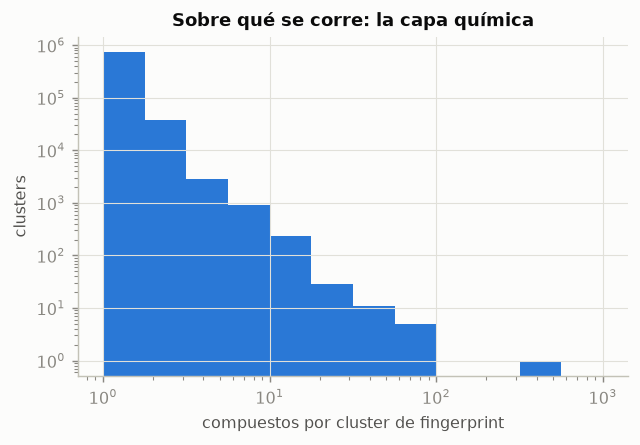

In [6]:
F.dibujar("02_f01_tamanos_cluster");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/figuras/02_f02_componentes_conexas.pdf


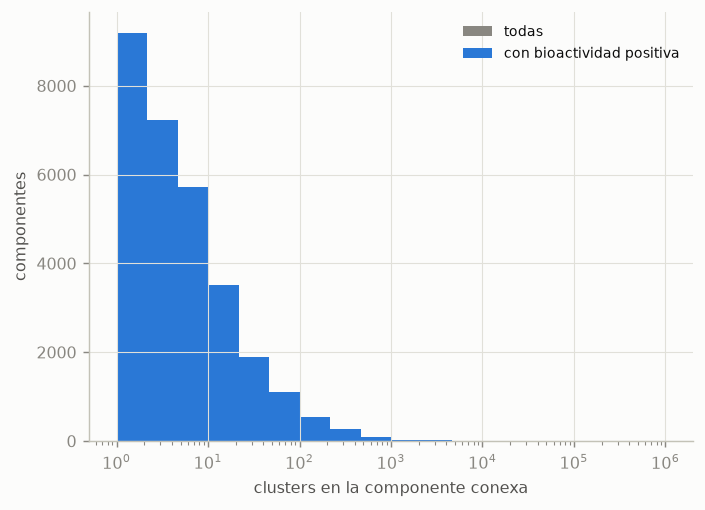

In [7]:
F.dibujar("02_f02_componentes_conexas");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/figuras/02_f03_conectividad_anotaciones.pdf


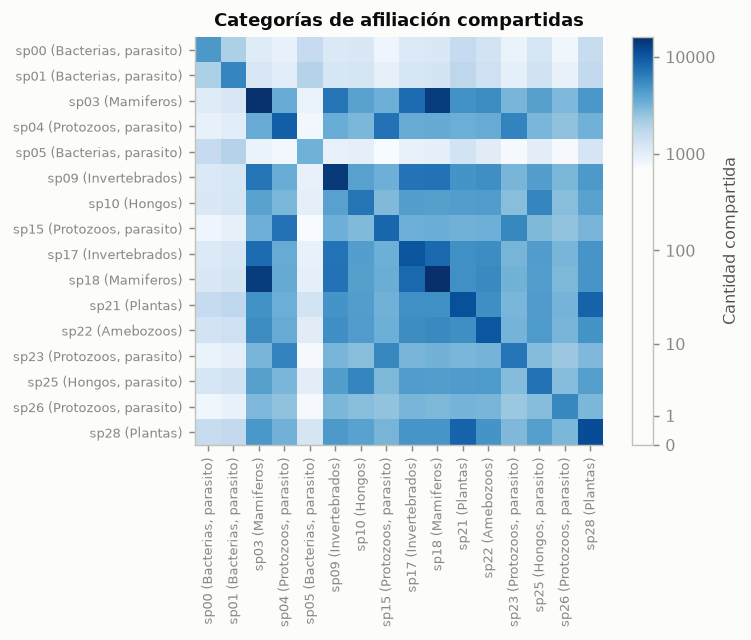

In [8]:
F.dibujar("02_f03_conectividad_anotaciones");

La misma conectividad como grafo (sección *Relevance Score* de `analiceDB/01` de v3): cada nodo es una especie y su área, el total de la capa
(la diagonal de la matriz); cada arista, lo que comparten dos especies. La disposición es kamada-kawai pesada por lo compartido: las especies que comparten más
quedan más cerca. Azul, anotaciones; naranja, compuestos con bioactividad positiva.

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/figuras/02_f04_grafo_anotaciones.pdf


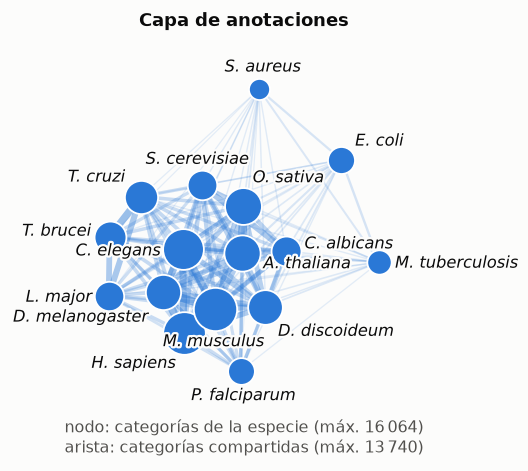

In [2]:
F.dibujar("02_f04_grafo_anotaciones");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/analiceDB_out/figuras/02_f05_grafo_drogas.pdf


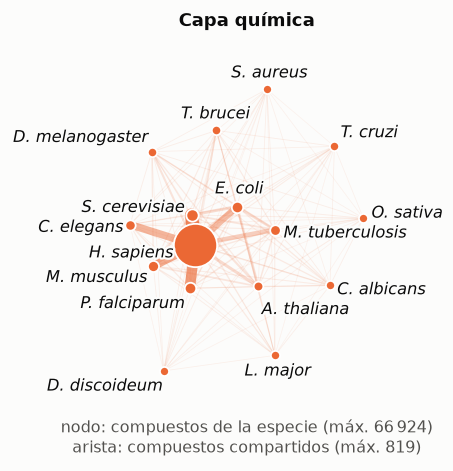

In [3]:
F.dibujar("02_f05_grafo_drogas");